# PURITY Training

Config-driven training/HPO/eval/export notebook for the PURITY plugin.

In [1]:
from __future__ import annotations

from datetime import datetime
from pathlib import Path

from pioneerml.integration.zenml import load_step_output
from pioneerml.integration.zenml import utils as zenml_utils

PROJECT_ROOT = zenml_utils.setup_repo_pythonpath(Path(zenml_utils.find_project_root()).resolve())
from pioneerml_purity_plugin.purity.pipeline import load_config, training_pipeline

zenml_utils.setup_zenml_for_notebook(root_path=PROJECT_ROOT, use_in_memory=True)
print('Project root:', PROJECT_ROOT)

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


Using ZenML repository root: /workspace
Ensure this is the top-level of your repo (.zen must live here).
Project root: /workspace


## Build Dummy Parquet

In [2]:
DATA_DIR = PROJECT_ROOT / 'data' / 'purity_inputs'

# Data selection knobs
USE_ALL_FILES = True
SINGLE_FILE = 'all_ml_000.parquet'
MAX_FILES = None  # Set an int only when USE_ALL_FILES=True.
TARGET_EVENTS_PER_SPLIT = None  # Set None to use full dataset.


def resolve_input_sources(data_dir: Path, *, use_all_files: bool, single_file: str, max_files: int | None = None) -> list[str]:
    if use_all_files:
        paths = sorted(data_dir.glob('*.parquet'))
        if max_files is not None:
            paths = paths[: int(max_files)]
    else:
        paths = [data_dir / single_file]

    missing = [str(p) for p in paths if not p.exists()]
    if missing:
        raise FileNotFoundError('Missing parquet input file(s):\n' + '\n'.join(missing))

    return [str(p.resolve()) for p in paths]


def estimate_total_events(parquet_paths: list[str]) -> int | None:
    try:
        import pyarrow.parquet as pq
    except Exception:
        return None
    total = 0
    for src in parquet_paths:
        try:
            pf = pq.ParquetFile(src)
            total += int(pf.metadata.num_rows)
        except Exception:
            continue
    return int(total) if total > 0 else None


input_sources = resolve_input_sources(
    DATA_DIR,
    use_all_files=USE_ALL_FILES,
    single_file=SINGLE_FILE,
    max_files=MAX_FILES,
)

total_input_events = estimate_total_events(input_sources)

print(f'Using {len(input_sources)} parquet input file(s):')
for src in input_sources[:10]:
    print(' -', src)
if len(input_sources) > 10:
    print(f' ... +{len(input_sources)-10} more')
print('Estimated total events across selected files:', total_input_events)
print('TARGET_EVENTS_PER_SPLIT:', TARGET_EVENTS_PER_SPLIT)

input_sources


Using 8 parquet input file(s):
 - /workspace/data/purity_inputs/all_ml_000.parquet
 - /workspace/data/purity_inputs/all_ml_001.parquet
 - /workspace/data/purity_inputs/all_ml_002.parquet
 - /workspace/data/purity_inputs/all_ml_003.parquet
 - /workspace/data/purity_inputs/all_ml_004.parquet
 - /workspace/data/purity_inputs/all_ml_005.parquet
 - /workspace/data/purity_inputs/all_ml_006.parquet
 - /workspace/data/purity_inputs/all_ml_007.parquet
Estimated total events across selected files: 64686
TARGET_EVENTS_PER_SPLIT: None


['/workspace/data/purity_inputs/all_ml_000.parquet',
 '/workspace/data/purity_inputs/all_ml_001.parquet',
 '/workspace/data/purity_inputs/all_ml_002.parquet',
 '/workspace/data/purity_inputs/all_ml_003.parquet',
 '/workspace/data/purity_inputs/all_ml_004.parquet',
 '/workspace/data/purity_inputs/all_ml_005.parquet',
 '/workspace/data/purity_inputs/all_ml_006.parquet',
 '/workspace/data/purity_inputs/all_ml_007.parquet']

## Load + Patch Plugin Config

In [3]:
cfg = load_config()['training']

# Guard knobs (training-time filtering)
GUARD_ROWS_ENABLED = True
GUARD_ROWS_TRAINING_ONLY = True
GUARD_REQUIRE_NONEMPTY_ATAR = True
GUARD_REQUIRE_NONEMPTY_TOTAL_HITS = True
GUARD_MAX_TOTAL_HITS = 300  # Set None to disable max-hit filtering.
GUARD_REQUIRE_FINITE_SCALARS = [
    'truth_theta',
    'truth_phi',
    'truth_positron_energy',
    'truth_pion_stop_x',
    'truth_pion_stop_y',
    'truth_pion_stop_z',
]

# Training-scale knobs (Omar suggestion: start with higher LR + more stage epochs)
FORCE_SAMPLE_FRACTION = None  # e.g. 0.1 to force 10%; None uses TARGET_EVENTS_PER_SPLIT.
USE_DEBUG_PHASE_SETTINGS = False
DEBUG_PHASE_LR = 5e-4
DEBUG_PHASE_EPOCHS = 8

# Omar-style optimizer defaults:
# - Parameter groups with faster event-module and scalar/bias learning rates
OMAR_OPTIMIZER_PARAM_GROUPS = [
    {
        'patterns': [
            r'^model\.impl\.(sigma_t_atar_ns|sigma_t_lyso_floor_ns|sigma_t_lyso_scale_ns|angle_sigma_floor|angle_sigma_scale|direction_bias_temperature|temporal_bias_sigma)$',
        ],
        'lr_scale': 10.0,
        'weight_decay': 0.0,
    },
    {
        'patterns': [
            r'^model\.impl\.(slim_event_transformer|lyso_event_proj|atar_event_down|event_head|event_head_proj|event_modality_emb|event_slice_emb)(\.|$)',
        ],
        'lr_scale': 5.0,
    },
    {
        'patterns': [r'^model\.'],
        'lr_scale': 1.0,
        'weight_decay': 1e-8,
    },
]


def resolve_sample_fraction(*, total_events: int | None, target_events: int | None, forced: float | None) -> float:
    if forced is not None:
        return float(max(1e-6, min(1.0, forced)))
    if target_events is None or total_events is None or int(total_events) <= 0:
        return 1.0
    return float(max(1e-6, min(1.0, float(target_events) / float(total_events))))


def patch_loader_sources(section_cfg: dict, source_paths: list[str]) -> None:
    lm = dict(section_cfg.get('loader_manager') or {})
    lm_cfg = dict(lm.get('config') or {})
    spec = dict(lm_cfg.get('input_sources_spec') or {})
    spec['main_sources'] = list(source_paths)
    spec['optional_sources_by_name'] = {}
    spec['source_type'] = 'file'
    lm_cfg['input_sources_spec'] = spec
    lm['config'] = lm_cfg
    section_cfg['loader_manager'] = lm


def patch_loader_sample_fraction(section_cfg: dict, *, sample_fraction: float) -> None:
    lm = dict(section_cfg.get('loader_manager') or {})
    lm_cfg = dict(lm.get('config') or {})
    defaults = dict(lm_cfg.get('defaults') or {})
    defaults_cfg = dict(defaults.get('config') or {})
    defaults_cfg['sample_fraction'] = float(sample_fraction)
    defaults['config'] = defaults_cfg
    lm_cfg['defaults'] = defaults

    # Also mirror into named loaders when present.
    loaders = dict(lm_cfg.get('loaders') or {})
    for lname, lspec in list(loaders.items()):
        lspec_dict = dict(lspec or {})
        lcfg = dict(lspec_dict.get('config') or {})
        lcfg['sample_fraction'] = float(sample_fraction)
        lspec_dict['config'] = lcfg
        loaders[lname] = lspec_dict
    lm_cfg['loaders'] = loaders

    lm['config'] = lm_cfg
    section_cfg['loader_manager'] = lm


def patch_guard_knobs(section_cfg: dict) -> None:
    lm = dict(section_cfg.get('loader_manager') or {})
    lm_cfg = dict(lm.get('config') or {})

    def apply_guard_params(target_cfg: dict) -> dict:
        out = dict(target_cfg or {})
        out['guard_rows_enabled'] = bool(GUARD_ROWS_ENABLED)
        out['guard_rows_training_only'] = bool(GUARD_ROWS_TRAINING_ONLY)
        out['guard_require_nonempty_atar'] = bool(GUARD_REQUIRE_NONEMPTY_ATAR)
        out['guard_require_nonempty_total_hits'] = bool(GUARD_REQUIRE_NONEMPTY_TOTAL_HITS)
        out['guard_max_total_hits'] = GUARD_MAX_TOTAL_HITS
        out['guard_require_finite_scalars'] = list(GUARD_REQUIRE_FINITE_SCALARS)
        return out

    defaults = dict(lm_cfg.get('defaults') or {})
    defaults_cfg = apply_guard_params(dict(defaults.get('config') or {}))
    defaults['config'] = defaults_cfg
    lm_cfg['defaults'] = defaults

    loaders = dict(lm_cfg.get('loaders') or {})
    for lname, lspec in list(loaders.items()):
        lspec_dict = dict(lspec or {})
        lcfg = apply_guard_params(dict(lspec_dict.get('config') or {}))
        lspec_dict['config'] = lcfg
        loaders[lname] = lspec_dict
    lm_cfg['loaders'] = loaders

    lm_cfg = apply_guard_params(lm_cfg)

    lm['config'] = lm_cfg
    section_cfg['loader_manager'] = lm


def patch_omar_optimizer_style(training_cfg: dict) -> None:
    for section_name in ('hpo', 'train'):
        sec = dict(training_cfg.get(section_name) or {})
        module_block = dict(sec.get('module') or {})
        module_cfg = dict(module_block.get('config') or {})
        module_cfg['optimizer_param_groups'] = [dict(g) for g in OMAR_OPTIMIZER_PARAM_GROUPS]
        module_block['config'] = module_cfg
        sec['module'] = module_block

        if section_name == 'train':
            staged = dict(sec.get('staged_training') or {})
            phases = list(staged.get('phases') or [])
            for i, phase in enumerate(phases):
                p = dict(phase or {})
                if USE_DEBUG_PHASE_SETTINGS:
                    p['max_epochs'] = int(DEBUG_PHASE_EPOCHS)
                    p['optimizer_overrides'] = {'lr': float(DEBUG_PHASE_LR), 'weight_decay': 0.0}
                phases[i] = p
            staged['phases'] = phases
            sec['staged_training'] = staged

        training_cfg[section_name] = sec


sample_fraction = resolve_sample_fraction(
    total_events=total_input_events,
    target_events=TARGET_EVENTS_PER_SPLIT,
    forced=FORCE_SAMPLE_FRACTION,
)

for name in ('hpo', 'train', 'evaluate', 'export'):
    sec = dict(cfg.get(name) or {})
    patch_loader_sources(sec, input_sources)
    patch_loader_sample_fraction(sec, sample_fraction=sample_fraction)
    patch_guard_knobs(sec)
    cfg[name] = sec

patch_omar_optimizer_style(cfg)

stamp = datetime.utcnow().strftime('%Y%m%d_%H%M%S')
cfg['hpo']['hpo']['config']['enabled'] = False
cfg['hpo']['hpo']['config']['n_trials'] = 1
cfg['hpo']['hpo']['config']['seed'] = 0
cfg['hpo']['hpo']['config']['storage'] = None
cfg['hpo']['hpo']['config']['study_name'] = f'purity_nb_hpo_{stamp}'
cfg['train']['trainer']['config']['trainer_kwargs']['max_epochs'] = 20
cfg['train']['trainer']['config']['early_stopping']['enabled'] = False

# Keep Omar staged behavior and skip evaluator (known unstable in this environment)
cfg['train']['staged_training']['enabled'] = True
cfg['evaluate']['enabled'] = False

export_cfg = dict(cfg['export']['exporter']['config'])
export_cfg['export_dir'] = str(PROJECT_ROOT / 'artifacts' / 'purity_notebook_export')
export_cfg['filename_prefix'] = f'purity_notebook_{stamp}'
cfg['export']['exporter']['config'] = export_cfg

print('sample_fraction:', sample_fraction)
print('Omar-style optimizer param groups:', len(cfg['train']['module']['config'].get('optimizer_param_groups') or []))
phase_cfg = []
for ph in list(cfg['train']['staged_training'].get('phases') or []):
    phase_cfg.append({
        'name': ph.get('name'),
        'max_epochs': ph.get('max_epochs'),
        'optimizer_overrides': dict(ph.get('optimizer_overrides') or {}),
    })
print('Phase schedule:', phase_cfg)

cfg.keys()


sample_fraction: 1.0
Omar-style optimizer param groups: 3
Phase schedule: [{'name': 'atar_bootstrap', 'max_epochs': 8, 'optimizer_overrides': {'lr': 0.0001, 'weight_decay': 0.0}}, {'name': 'atar_trigger_slice', 'max_epochs': 4, 'optimizer_overrides': {'lr': 1e-05, 'weight_decay': 0.0}}, {'name': 'downstream_kinematics', 'max_epochs': 4, 'optimizer_overrides': {'lr': 1e-05, 'weight_decay': 0.0}}, {'name': 'event_fusion', 'max_epochs': 4, 'optimizer_overrides': {'lr': 1e-05, 'weight_decay': 0.0}}]


dict_keys(['hpo', 'train', 'evaluate', 'export'])

## Run Training Pipeline

In [4]:
run = training_pipeline.with_options(enable_cache=False)(pipeline_config=cfg)

Initiating a new run for the pipeline: training_pipeline.
Caching is disabled by default for training_pipeline.
Using user: default
Using stack: default
  deployer: default
  artifact_store: default
  orchestrator: default
You can visualize your pipeline runs in the ZenML Dashboard. In order to try it locally, please run zenml login --local.
Step tune_model has started.
Step tune_model has finished in 0.212s.
Step train_model has started.
[train_model] GPU available: True (cuda), used: True
[train_model] TPU available: False, using: 0 TPU cores
[train_model] 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
[train_model] [purity_staged_training] phase=atar_bootstrap freeze_all=False trainable_patterns=0 freeze_patterns=0 unfreeze_patterns=0 trainable_parameters=6164378 frozen_parameters=0
[train_model] [purit

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ PurityModel       │  6.2 M │ train │     0 │
│ 1 │ loss_fn │ PurityUnifiedLoss │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 6.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.2 M                                                                                                
Total estimated model params size (MB): 24                                                                         
Modules in train mode: 318                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

[train_model] loader_epoch_summary mode=train split=train usable_graphs=50304 batch_sizes=[128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128,

...

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ PurityModel       │  6.2 M │ train │     0 │
│ 1 │ loss_fn │ PurityUnifiedLoss │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 6.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.2 M                                                                                                
Total estimated model params size (MB): 24                                                                         
Modules in train mode: 318                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

[train_model] loader_epoch_summary mode=train split=train usable_graphs=50304 batch_sizes=[128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128,

[train_model] [purity_staged_training] phase=event_fusion train_loss_points=4 val_loss_points=5
Step train_model has finished in 3h56m9s.
Step evaluate_model has started.
Step evaluate_model has finished in 0.311s.
Step export_model has started.
Step export_model has finished in 4.486s.
Pipeline run has finished in 3h56m16s.


### Training Curves
Quick visual check that train/val loss behaves as expected.


hpo: {}
metrics keys: ['skipped']
metrics: skipped (disabled for notebook smoke data)
export: {'torchscript_path': '/workspace/artifacts/purity_notebook_export/purity_notebook_20260424_171411_20260424_211024_torchscript.pt', 'metadata_path': '/workspace/artifacts/purity_notebook_export/purity_notebook_20260424_171411_20260424_211024_meta.json', 'export_type': 'script', 'exporter_type': 'torchscript'}
num staged phases captured: 4


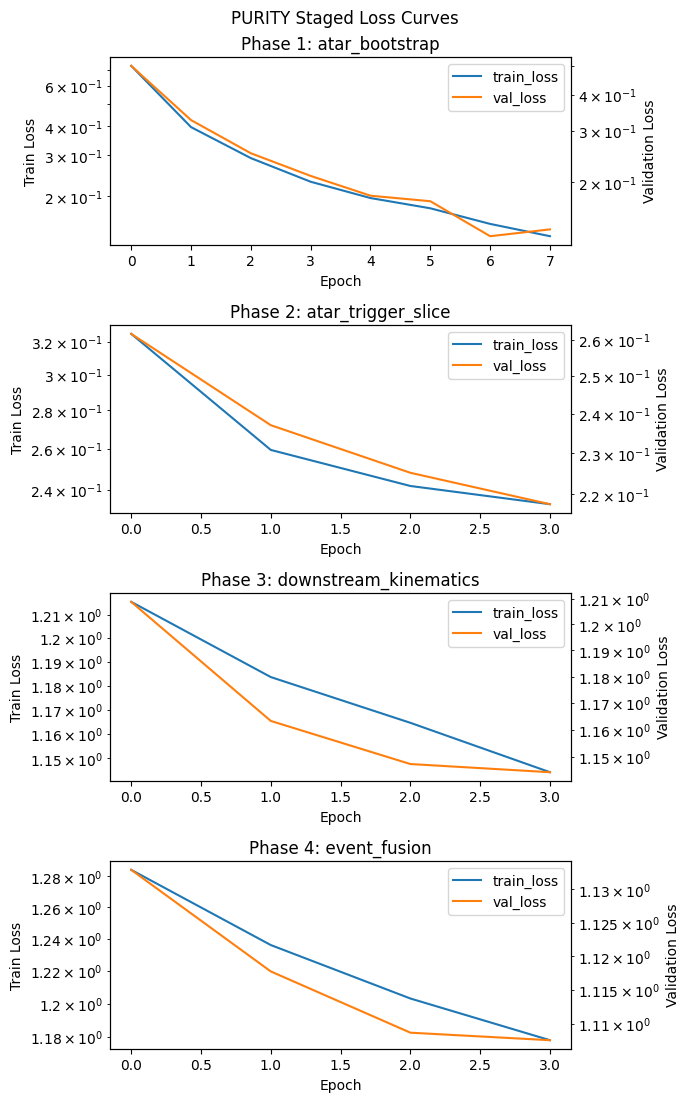

pdg accuracy points: {'train_batches': 7860, 'val_batches': 1088}


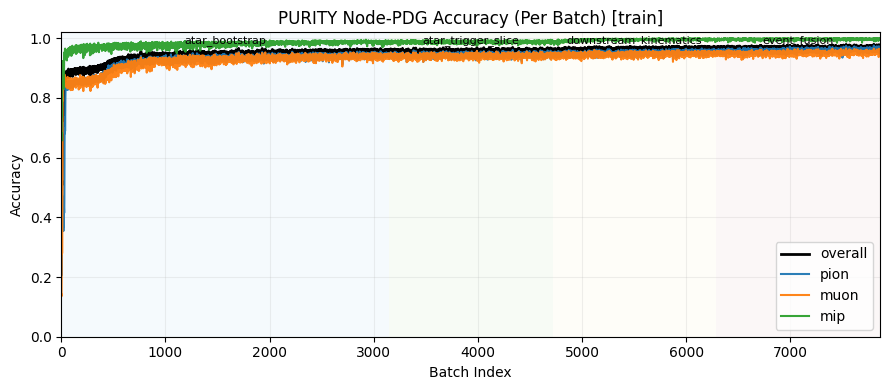

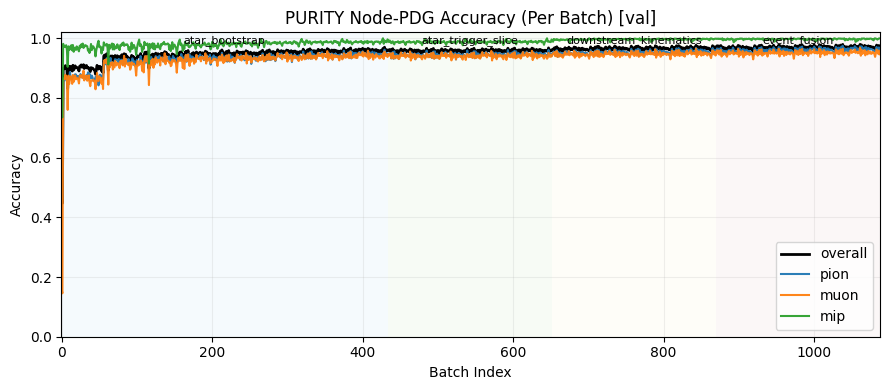

endpoint mse points: {'train_batches': 7860, 'val_batches': 1088}


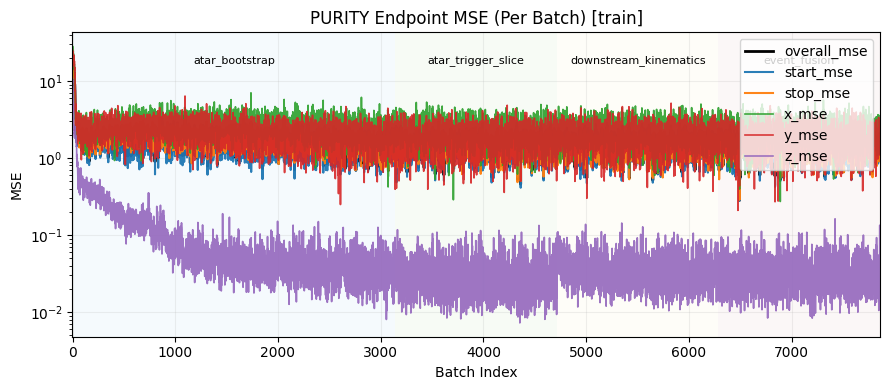

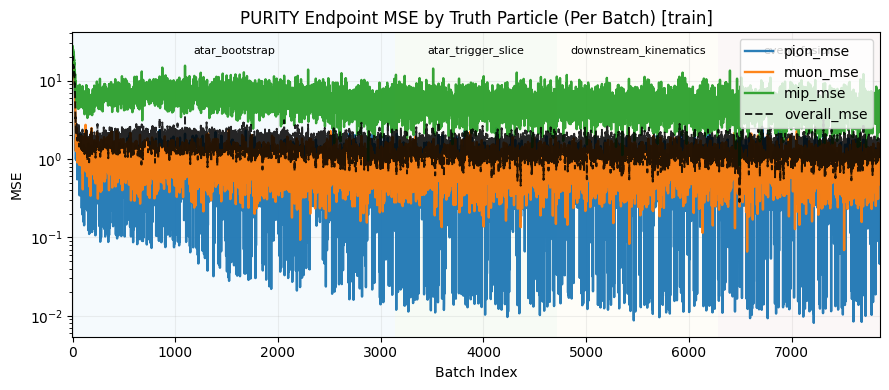

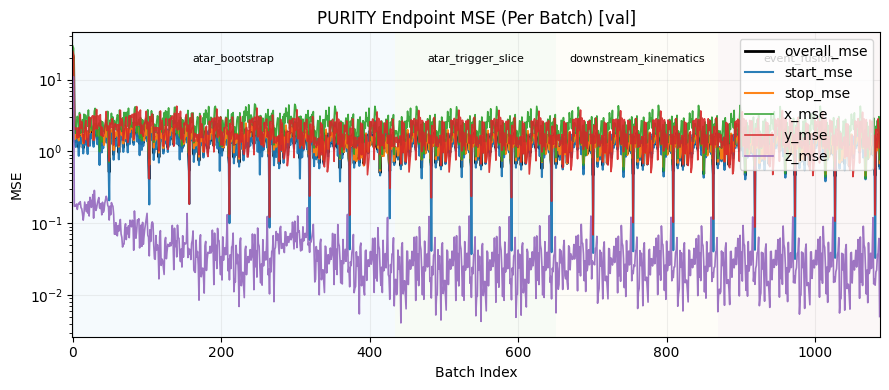

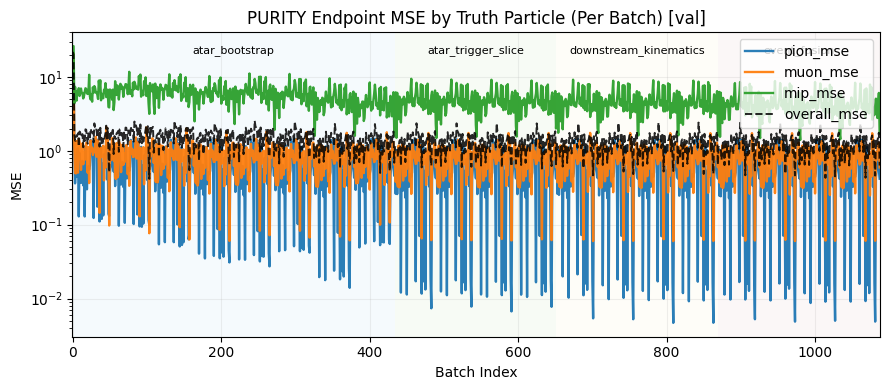

task diagnostics points: {'train_batches': 7860, 'val_batches': 1088}


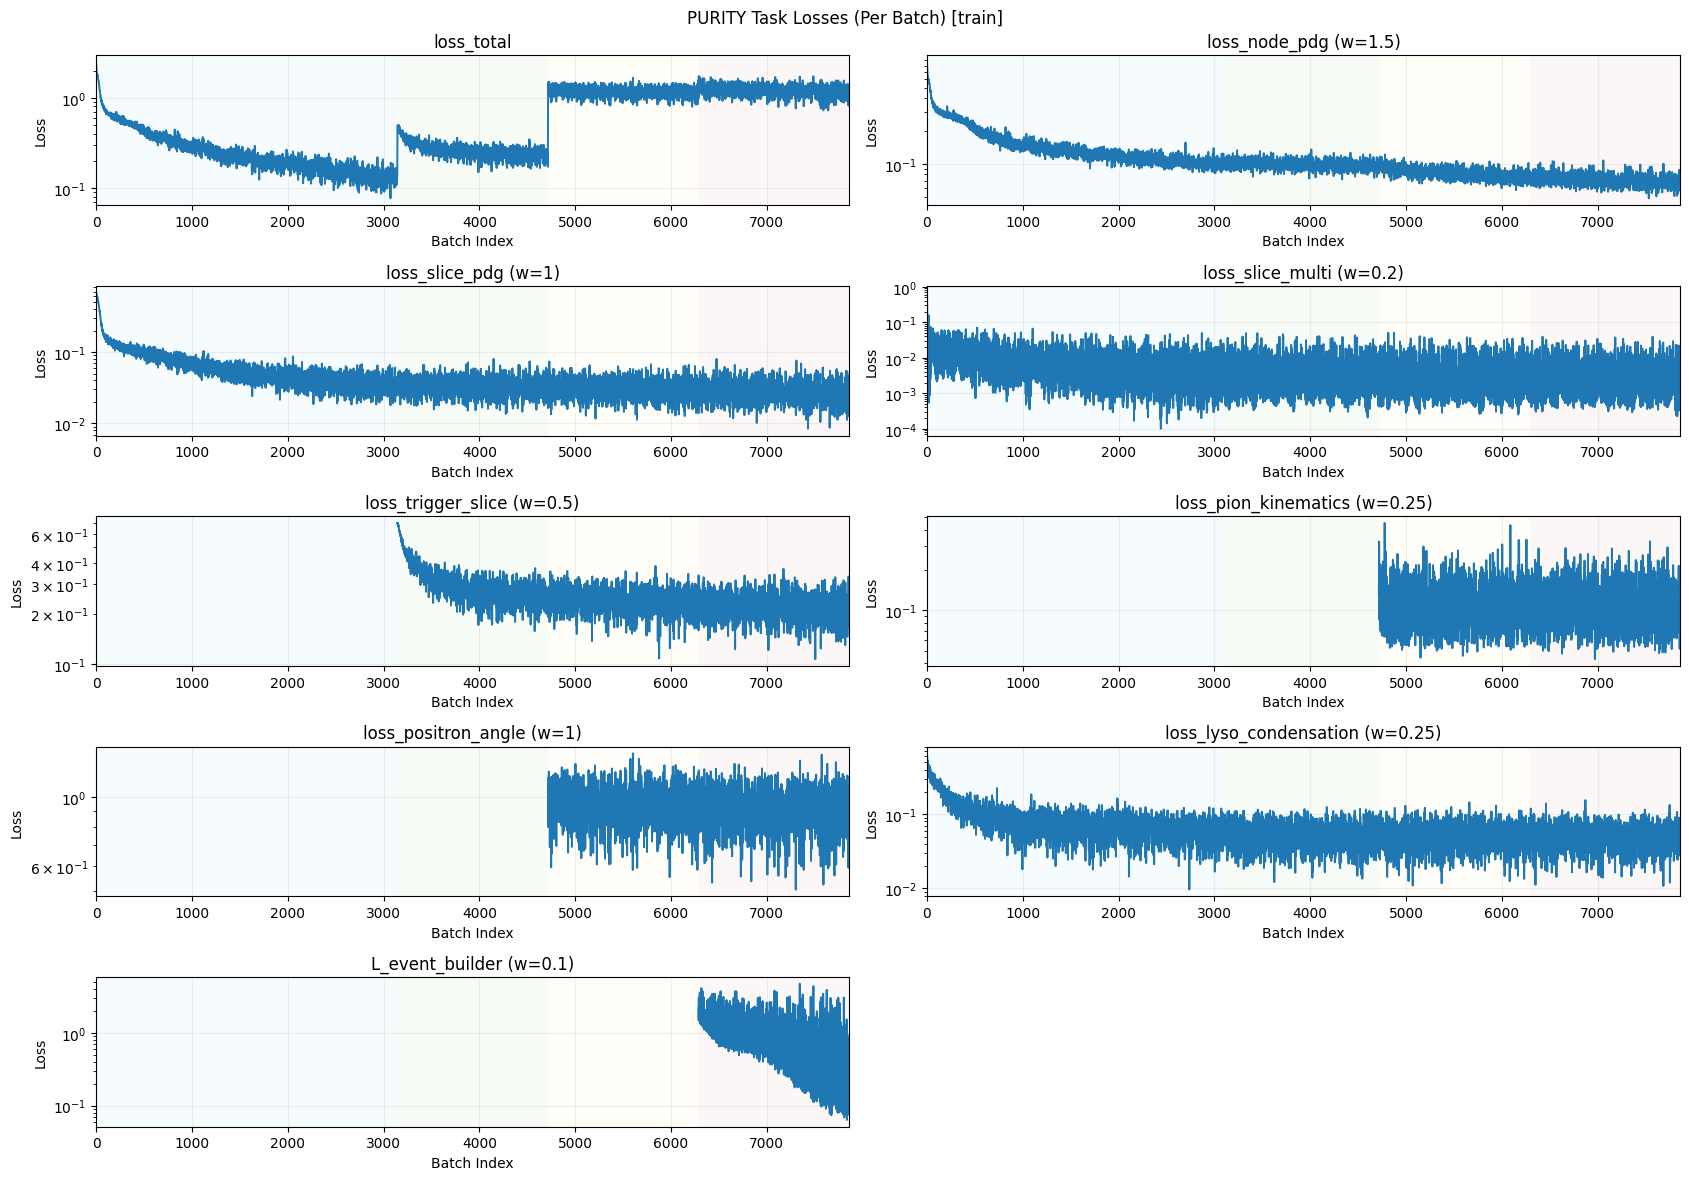

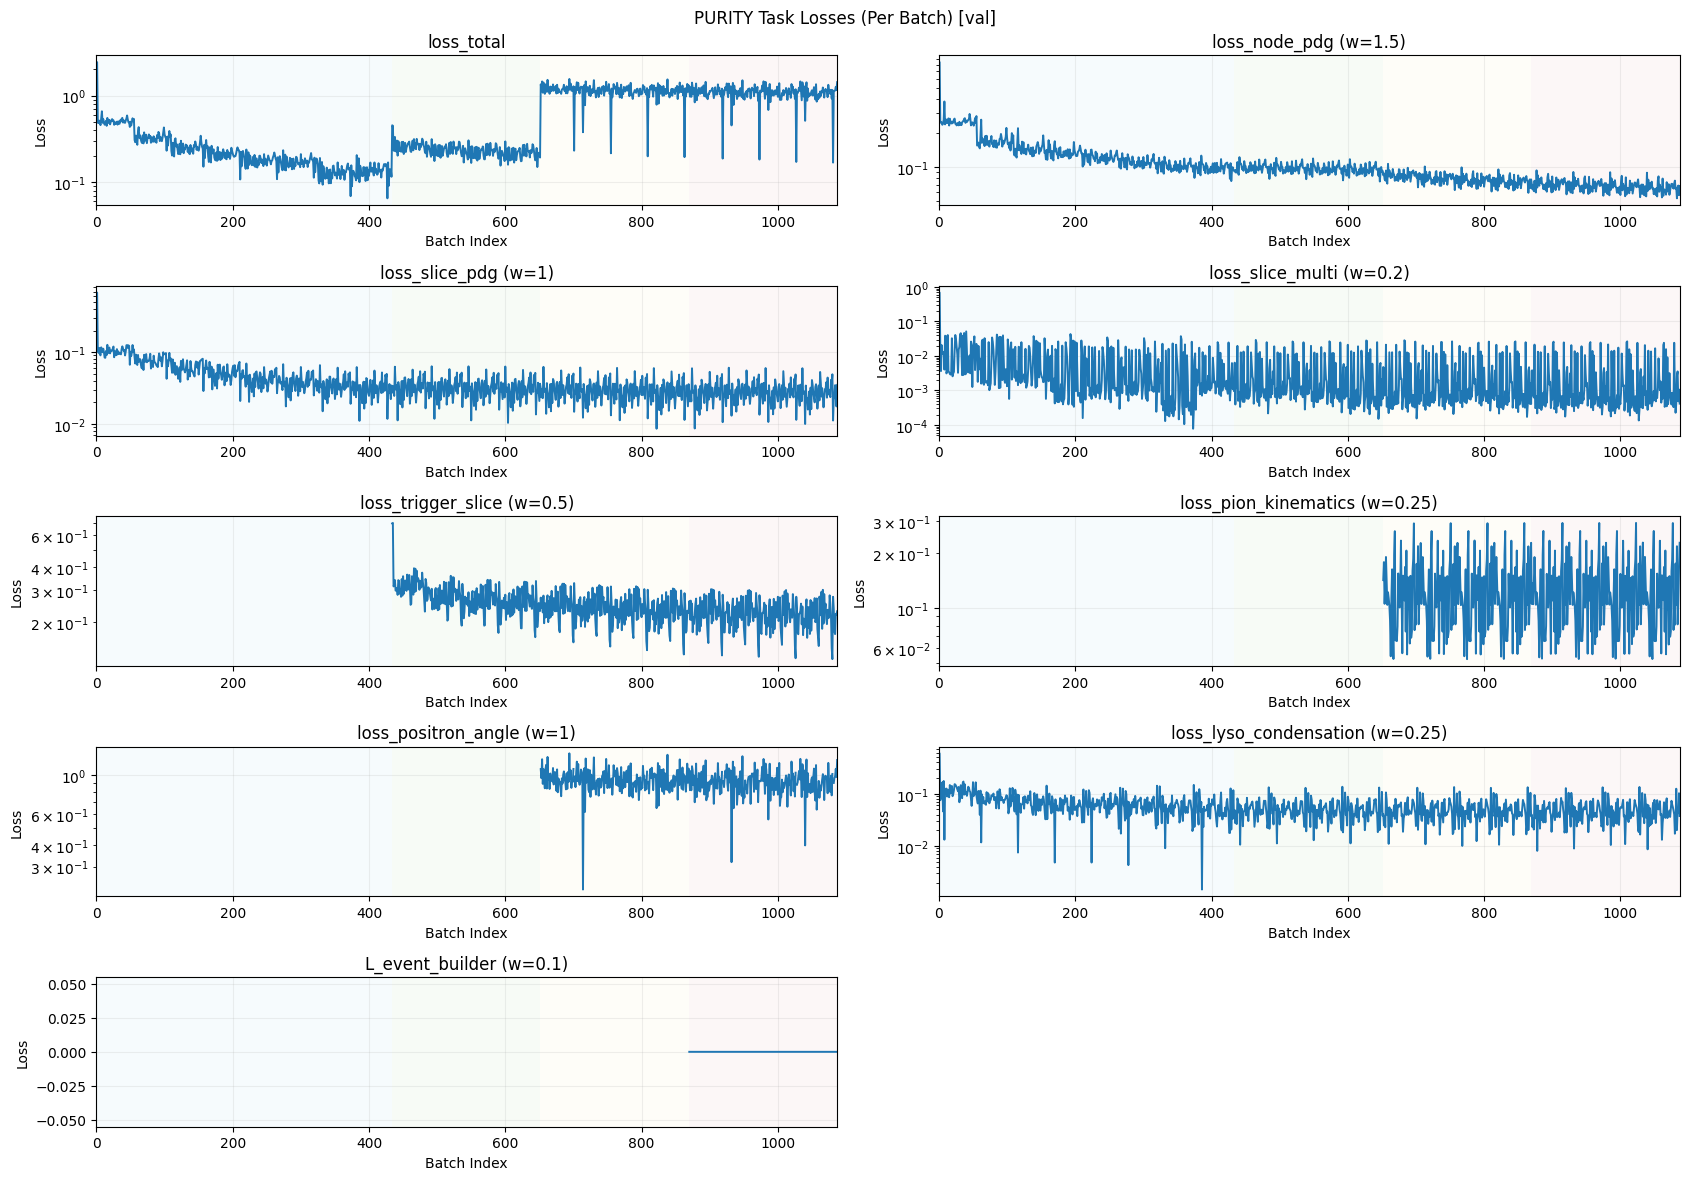

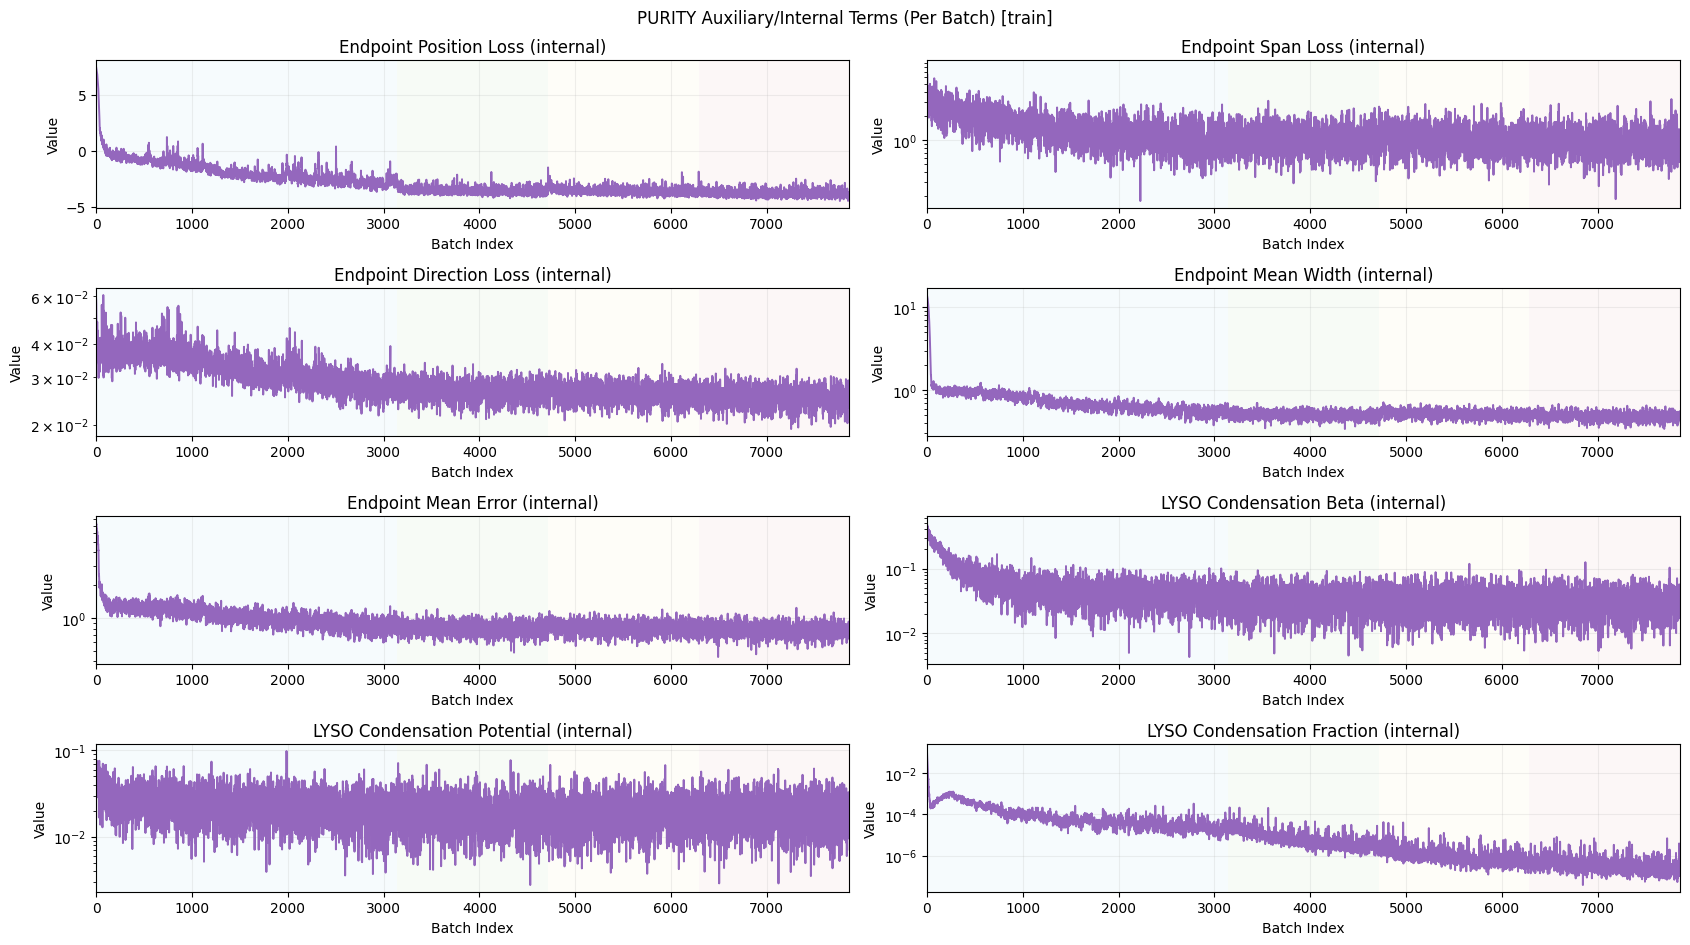

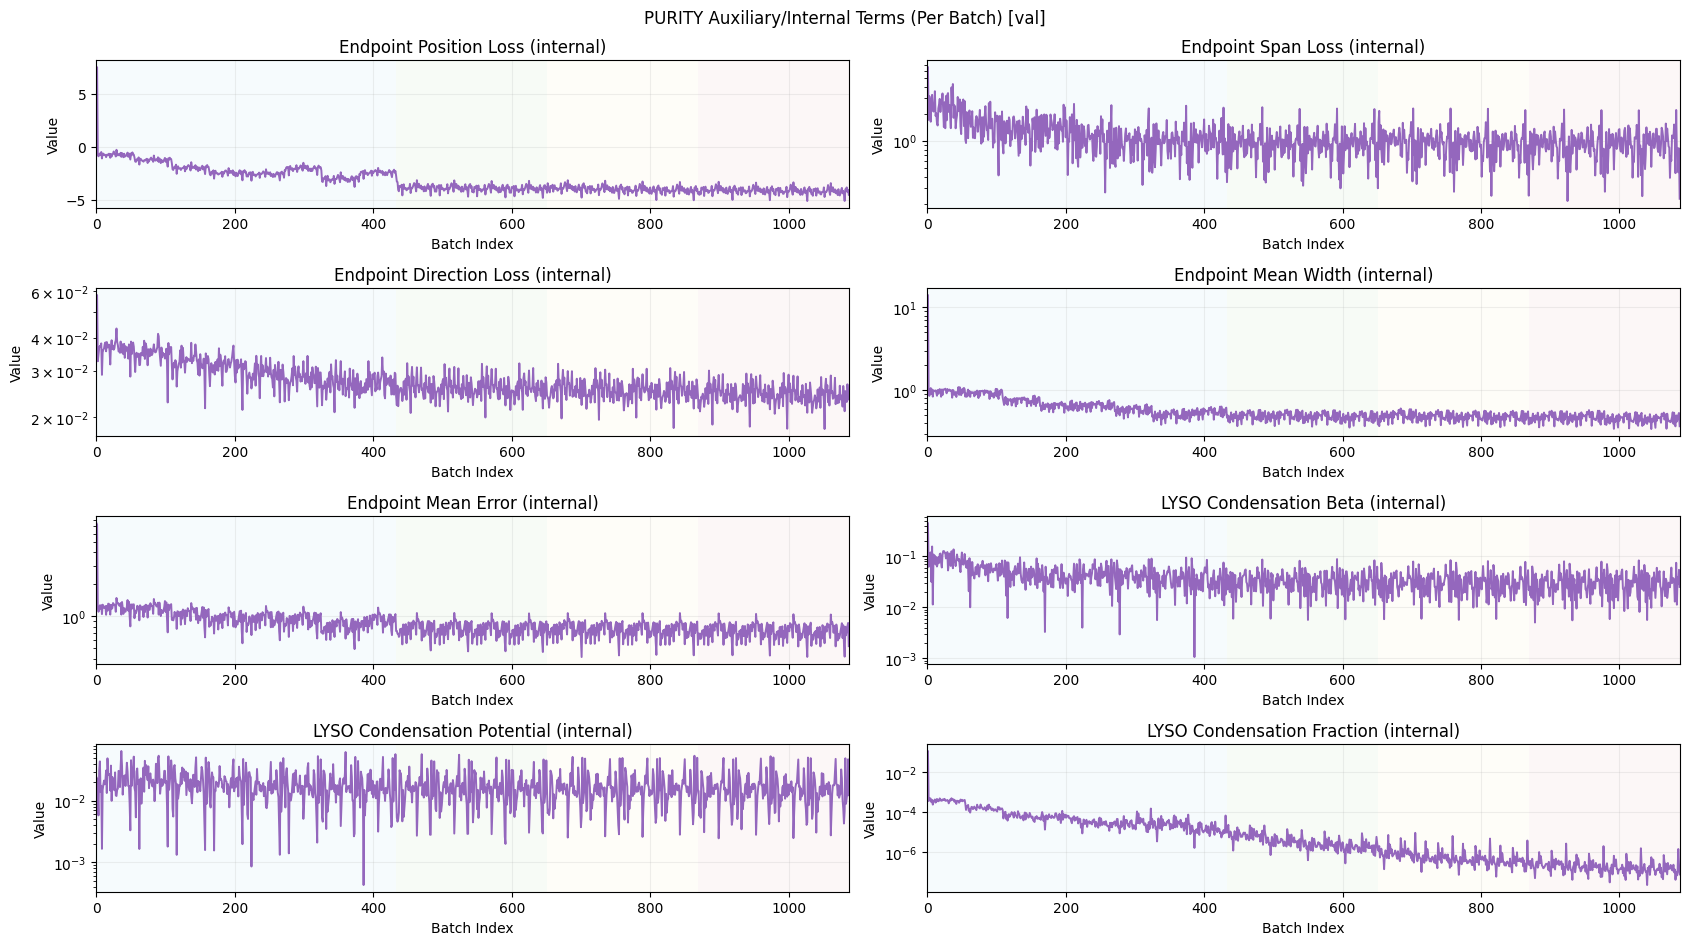

In [5]:
from pioneerml.evaluation.plots import plot_loss_curves
from pioneerml_purity_plugin.purity.evaluation.plots import (
    plot_purity_endpoint_mse_by_particle_curves,
    plot_purity_endpoint_mse_curves,
    plot_purity_pdg_accuracy_curves,
    plot_purity_staged_loss_curves,
    plot_purity_task_aux_curves,
    plot_purity_task_loss_curves,
)

hpo_output = load_step_output(run, 'tune_model')
train_output = load_step_output(run, 'train_model')
if bool((cfg.get('evaluate') or {}).get('enabled', True)):
    eval_output = load_step_output(run, 'evaluate_model')
else:
    eval_output = {'metrics': {'skipped': 'evaluation disabled by config'}}
export_output = load_step_output(run, 'export_model')

metrics = dict((eval_output or {}).get('metrics') or {})
print('hpo:', (hpo_output or {}).get('hpo_params'))
print('metrics keys:', sorted(metrics.keys()))
if metrics and 'skipped' not in metrics:
    parity_keys = [
        'loss_total', 'loss_atar_slice_multi', 'loss_node_pdg', 'loss_atar_edge',
        'loss_slice_pdg', 'loss_endpoints', 'loss_lyso_condensation', 'loss_event_builder',
    ]
    print('selected metrics:', {k: metrics.get(k) for k in parity_keys if k in metrics})
else:
    print('metrics: skipped (disabled for notebook smoke data)')
print('export:', export_output)

trained_module = (train_output or {}).get('module') if isinstance(train_output, dict) else None
if trained_module is None:
    raise RuntimeError('train_output is missing module; cannot plot loss curves.')

phase_histories = list(getattr(trained_module, 'staged_phase_loss_histories', []) or [])
print(f'num staged phases captured: {len(phase_histories)}')

# 1) Total staged loss (epoch curves)
if phase_histories:
    plot_purity_staged_loss_curves(module=trained_module, show=True)
else:
    print('No staged phase histories found; falling back to aggregate loss plot.')
    plot_loss_curves(
        getattr(trained_module, 'train_epoch_loss_history', []),
        getattr(trained_module, 'val_epoch_loss_history', []),
        title='PURITY: Loss Curves',
        show=True,
    )

# 2) Node-PDG accuracy (per-batch, phase regions)
train_pdg_hist = list(getattr(trained_module, 'train_pdg_batch_accuracy_history', []) or [])
val_pdg_hist = list(getattr(trained_module, 'val_pdg_batch_accuracy_history', []) or [])
print('pdg accuracy points:', {'train_batches': len(train_pdg_hist), 'val_batches': len(val_pdg_hist)})
if train_pdg_hist:
    plot_purity_pdg_accuracy_curves(module=trained_module, split='train', show=True)
if val_pdg_hist:
    plot_purity_pdg_accuracy_curves(module=trained_module, split='val', show=True)

# 3) Endpoint MSE curves (per-batch, phase regions)
train_endpoint_hist = list(getattr(trained_module, 'train_endpoint_mse_batch_history', []) or [])
val_endpoint_hist = list(getattr(trained_module, 'val_endpoint_mse_batch_history', []) or [])
print('endpoint mse points:', {'train_batches': len(train_endpoint_hist), 'val_batches': len(val_endpoint_hist)})
if train_endpoint_hist:
    plot_purity_endpoint_mse_curves(module=trained_module, split='train', show=True)
    plot_purity_endpoint_mse_by_particle_curves(module=trained_module, split='train', show=True)
if val_endpoint_hist:
    plot_purity_endpoint_mse_curves(module=trained_module, split='val', show=True)
    plot_purity_endpoint_mse_by_particle_curves(module=trained_module, split='val', show=True)

# 4) Task-level weighted losses (optimized objectives)
train_task_hist = list(getattr(trained_module, 'train_task_diagnostics_batch_history', []) or [])
val_task_hist = list(getattr(trained_module, 'val_task_diagnostics_batch_history', []) or [])
print('task diagnostics points:', {'train_batches': len(train_task_hist), 'val_batches': len(val_task_hist)})
if train_task_hist:
    plot_purity_task_loss_curves(module=trained_module, split='train', show=True)
if val_task_hist:
    plot_purity_task_loss_curves(module=trained_module, split='val', show=True)

# 5) Auxiliary/internal terms (endpoint + lyso internals; not weighted task objectives)
if train_task_hist:
    plot_purity_task_aux_curves(module=trained_module, split='train', show=True)
if val_task_hist:
    plot_purity_task_aux_curves(module=trained_module, split='val', show=True)


### Error Diagnostics
Validation-time error and distribution plots for model outputs.


endpoint histogram predicted counts: {'pion': {'x': 14432, 'y': 14432, 'z': 14432}, 'muon': {'x': 14624, 'y': 14624, 'z': 14624}, 'mip': {'x': 4776, 'y': 4776, 'z': 4776}}
endpoint histogram truth counts: {'pion': {'x': 14432, 'y': 14432, 'z': 14432}, 'muon': {'x': 14624, 'y': 14624, 'z': 14624}, 'mip': {'x': 4776, 'y': 4776, 'z': 4776}}


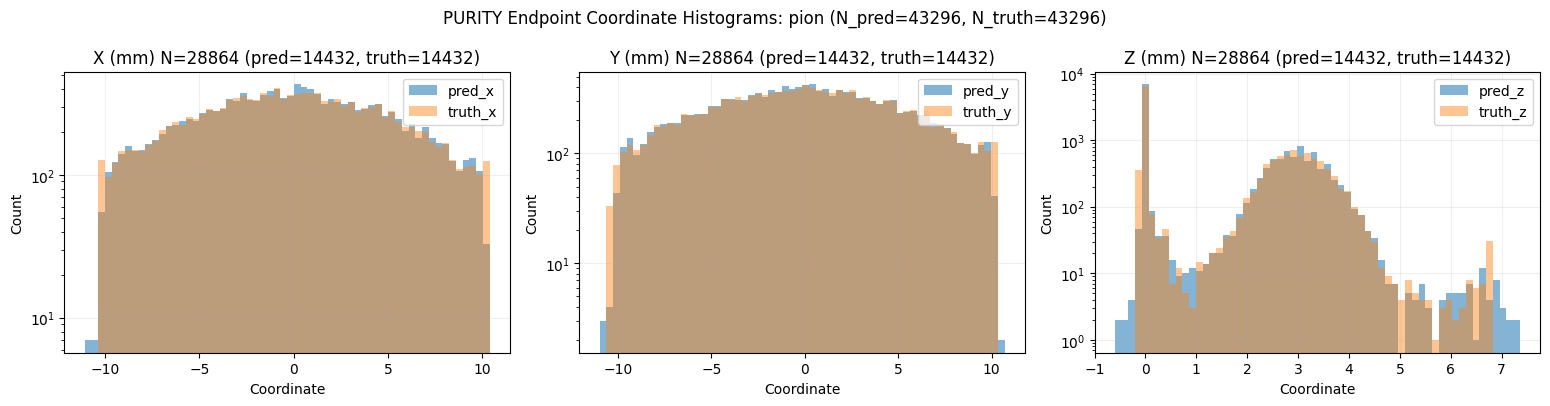

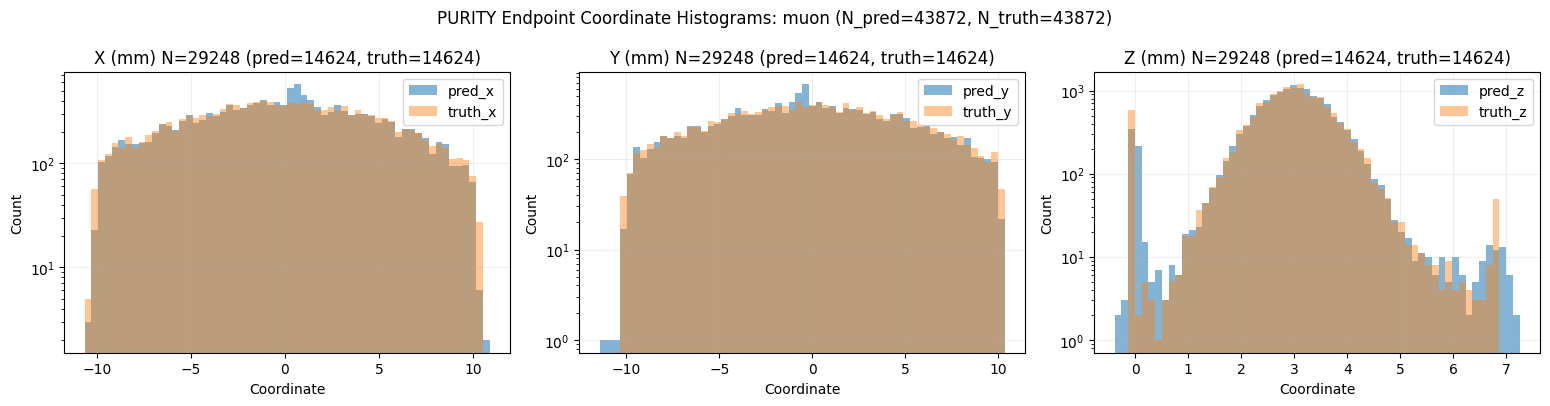

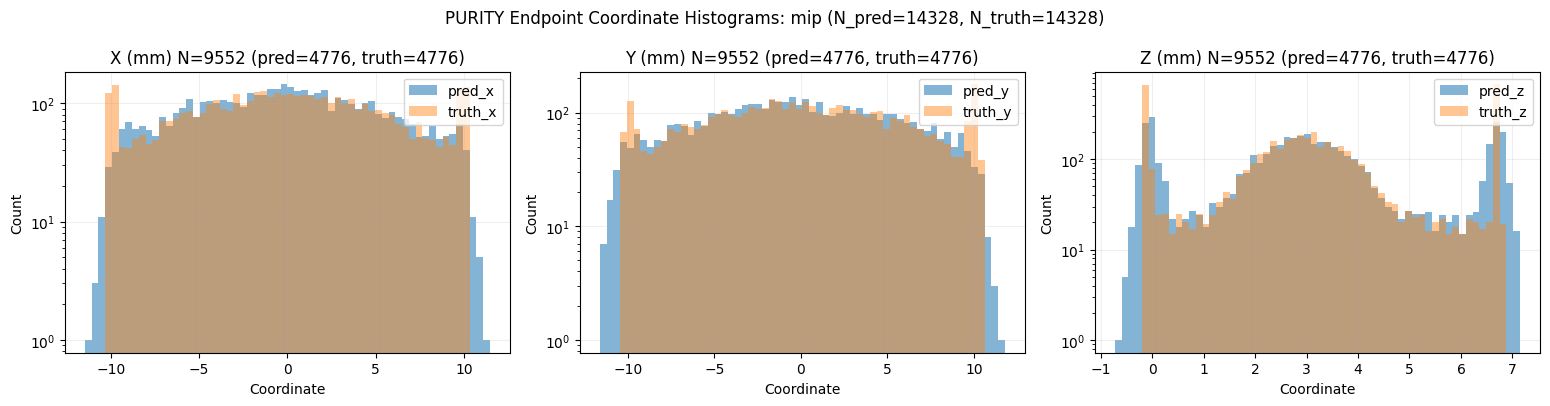

endpoint histogram predicted counts: {'pion': {'x': 14432, 'y': 14432, 'z': 14432}, 'muon': {'x': 14624, 'y': 14624, 'z': 14624}, 'mip': {'x': 4776, 'y': 4776, 'z': 4776}}
endpoint histogram truth counts: {'pion': {'x': 14432, 'y': 14432, 'z': 14432}, 'muon': {'x': 14624, 'y': 14624, 'z': 14624}, 'mip': {'x': 4776, 'y': 4776, 'z': 4776}}


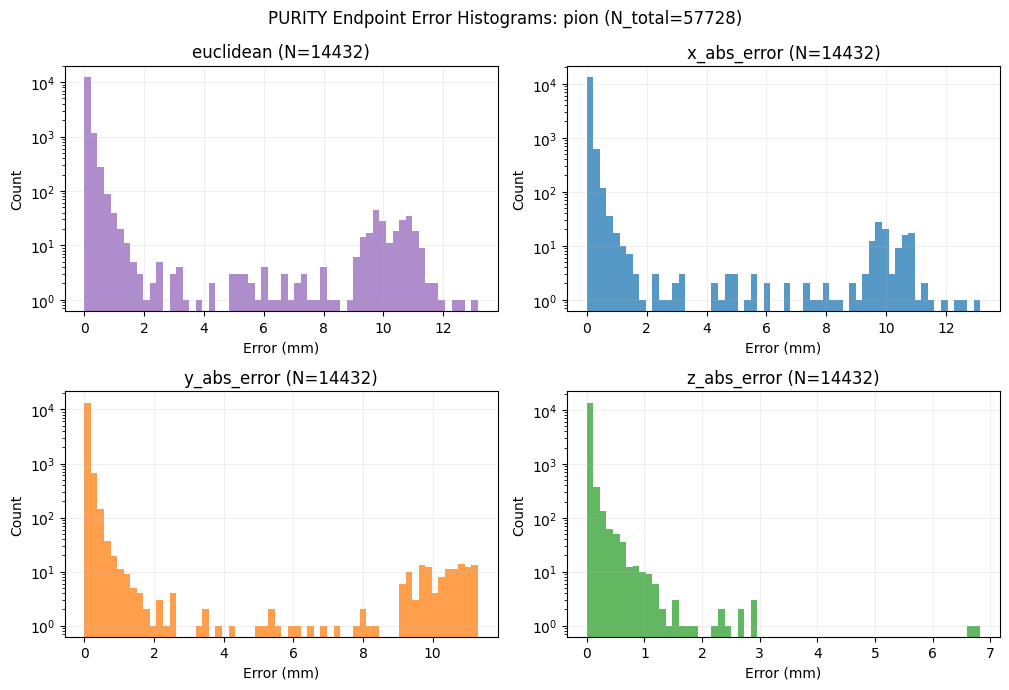

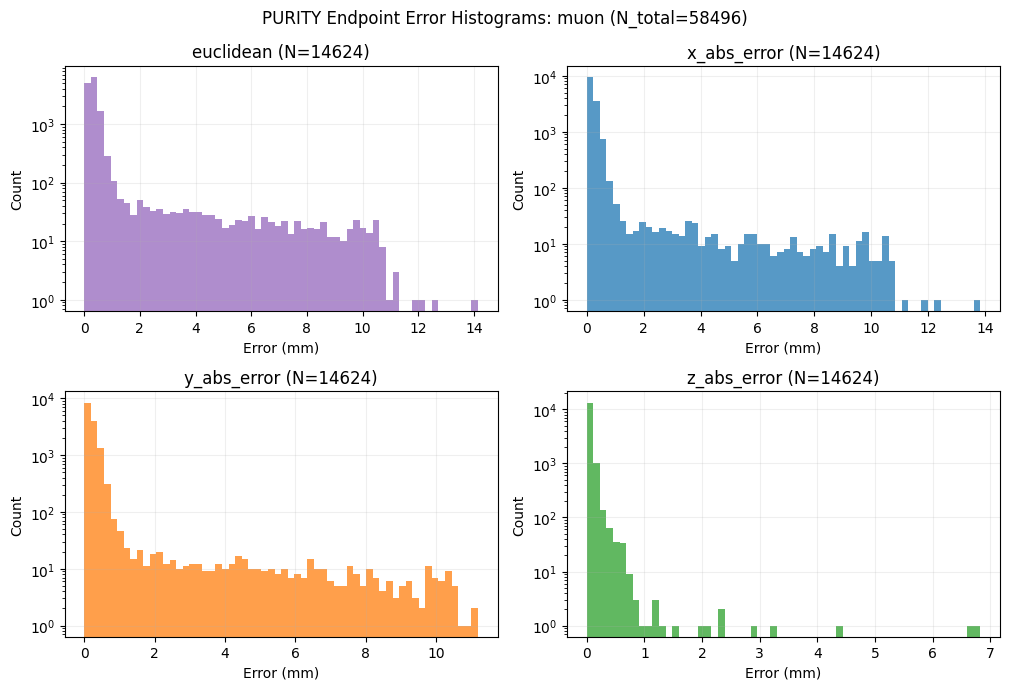

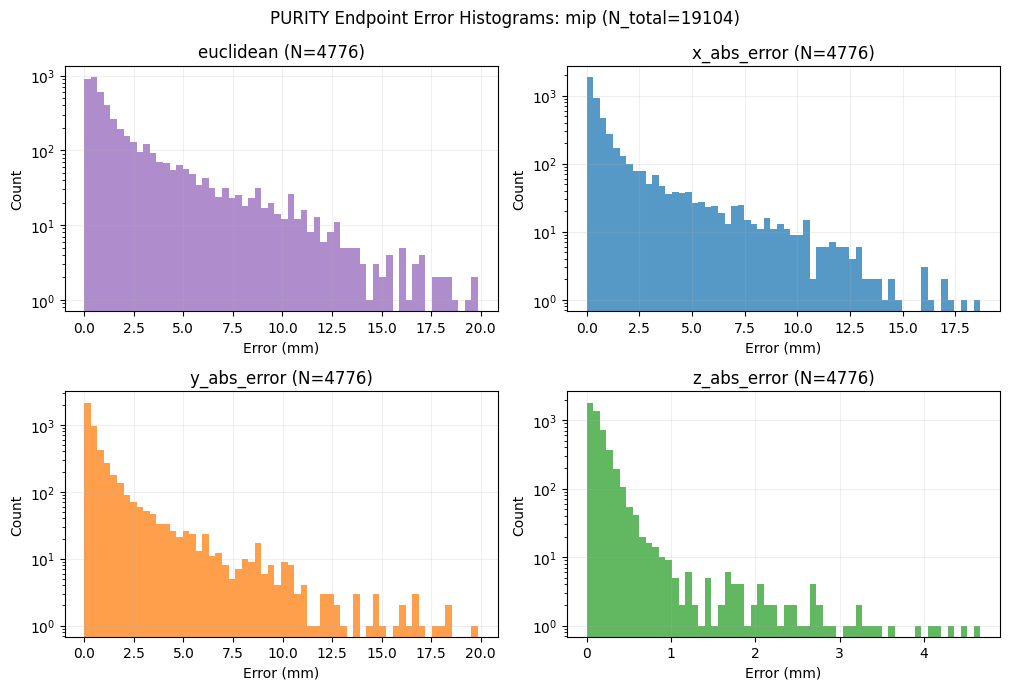

target_diag sizes: {'node_conf': 9, 'slice_conf': 9, 'trig_scores': 16392, 'trig_truth': 16392, 'multi_scores': 16392, 'multi_truth': 16392, 'event_scores': 29542, 'event_truth': 29542, 'pion_euclid': 5849, 'pion_dx': 5849, 'pion_dy': 5849, 'pion_dz': 5849, 'theta_diff_deg': 1133, 'theta_pred_deg': 1133, 'theta_truth_deg': 1133, 'angle_cos_err': 1133, 'energy_pred': 6346, 'energy_truth': 6346, 'time_pred': 6346, 'time_truth_proxy': 6346, 'accepted_vals': 6346, 'time_sentinel_threshold': 'matrix', 'energy_pred_plot': 6346, 'energy_truth_plot': 6346, 'energy_scale_factor': 'matrix', 'energy_scale_reason': 'matrix', 'time_pred_filtered': 1017, 'time_truth_proxy_filtered': 1017}
target_diag stats: {'batches_processed': 54, 'graphs_seen': 6346, 'trig_pairs_total': 16392, 'multi_pairs_total': 16392, 'event_pairs_total': 29542, 'event_tokens_total': 29542, 'event_tokens_atar': 16392, 'event_tokens_lyso': 13150, 'event_tokens_truth_defined': 29542, 'event_tokens_truth_graph_fallback': 3466, 'p

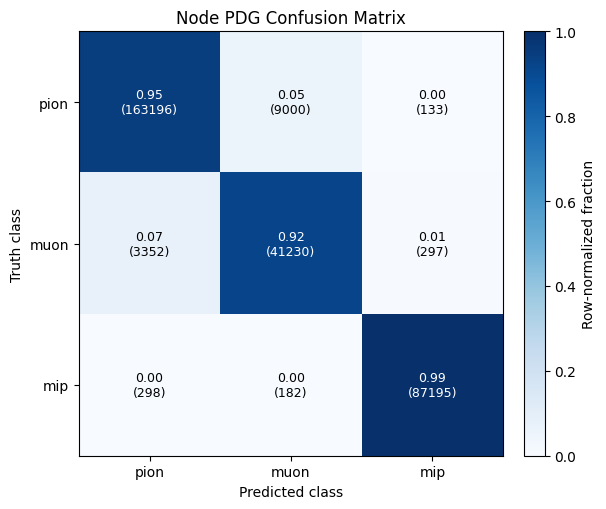

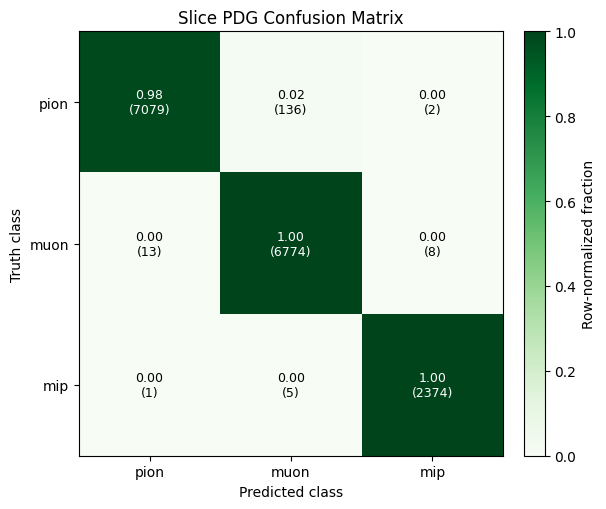

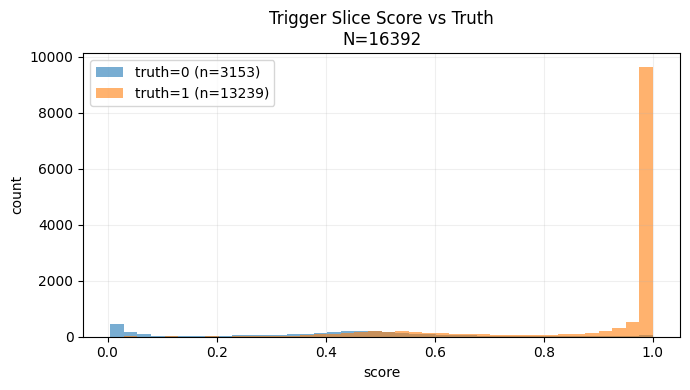

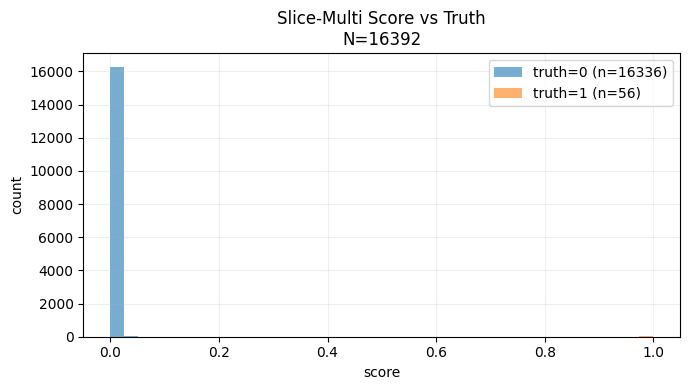

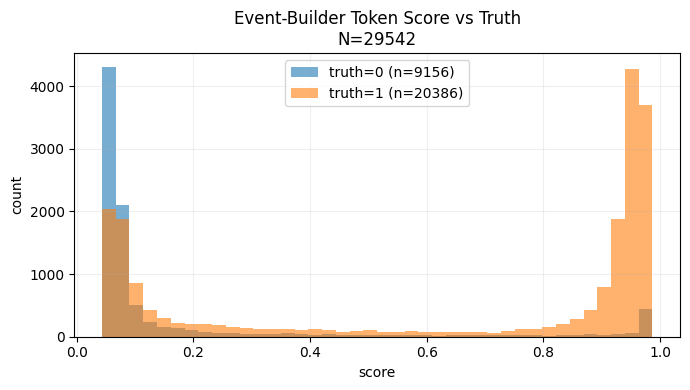

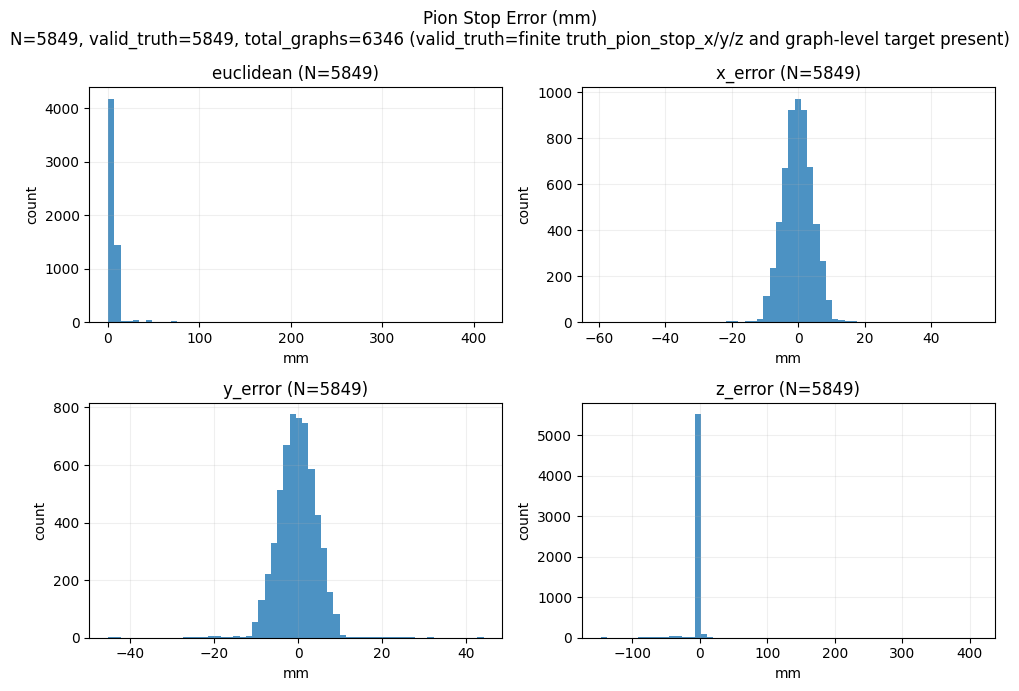

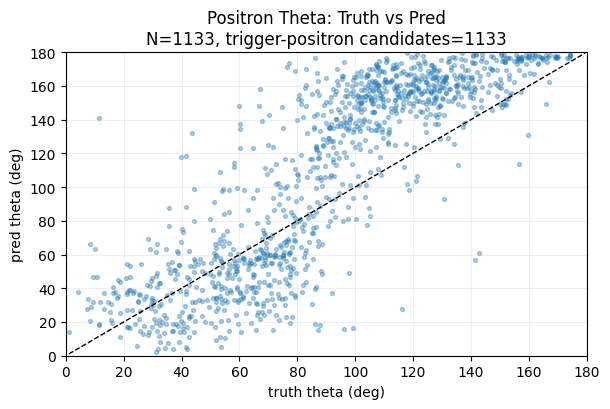

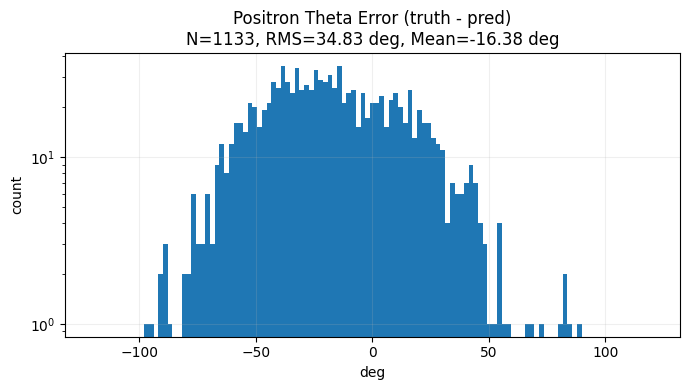

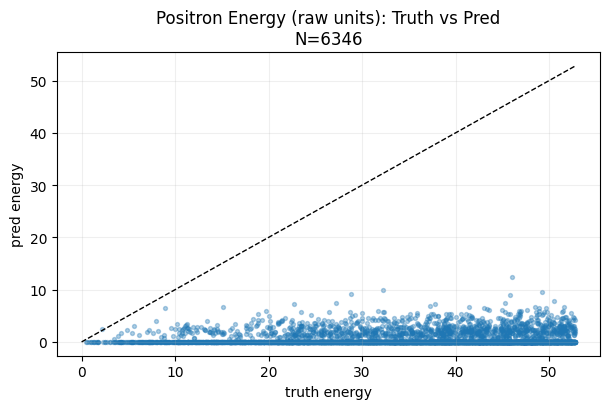

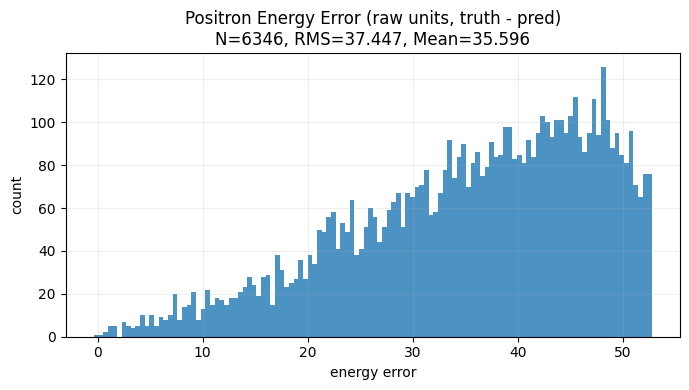

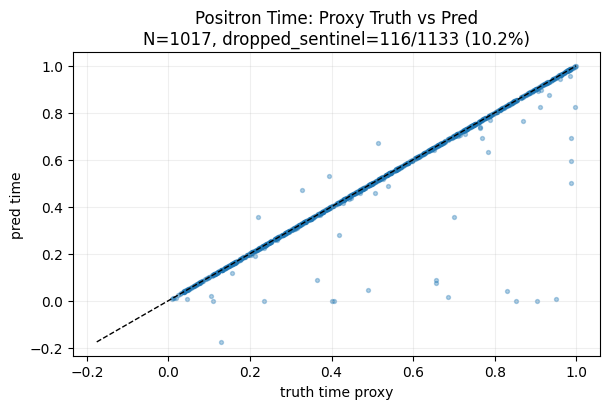

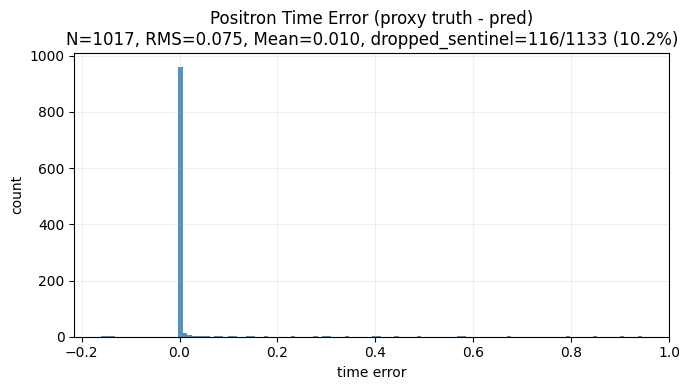

In [6]:
from pioneerml_purity_plugin.purity.evaluation.plots import (
    collect_purity_target_diagnostics,
    plot_purity_endpoint_error_histograms_by_particle,
    plot_purity_endpoint_pred_truth_histograms_by_particle,
    plot_purity_event_builder_score_hist,
    plot_purity_node_pdg_class_accuracy,
    plot_purity_pion_stop_error_hist,
    plot_purity_positron_angle_error_hist,
    plot_purity_positron_theta_scatter,
    plot_purity_positron_energy_scatter,
    plot_purity_positron_energy_error_hist,
    plot_purity_positron_time_scatter,
    plot_purity_positron_time_error_hist,
    plot_purity_slice_multi_score_hist,
    plot_purity_slice_pdg_class_accuracy,
    plot_purity_trigger_slice_score_hist,
)
from pioneerml.data_loader import LoaderManagerFactory


def _build_val_dataloader_from_train_cfg(train_cfg: dict):
    lm_cfg = dict(train_cfg['loader_manager']['config'])
    manager = LoaderManagerFactory(loader_manager_name='config').build(config=lm_cfg)
    val_params = manager.resolve_loader_params(purpose='val')
    val_loader_obj = manager.loader_factory.build(config=val_params)
    return val_loader_obj.make_dataloader(shuffle_batches=False)


try:
    val_dl = _build_val_dataloader_from_train_cfg(cfg['train'])

    plot_purity_endpoint_pred_truth_histograms_by_particle(
        module=trained_module,
        val_dataloader=val_dl,
        particle_order=('pion', 'muon', 'mip'),
        coord_order=('x', 'y', 'z'),
        max_batches=100,
        bins=60,
        show=True,
        verbose=True,
    )

    plot_purity_endpoint_error_histograms_by_particle(
        module=trained_module,
        val_dataloader=val_dl,
        particle_order=('pion', 'muon', 'mip'),
        coord_order=('x', 'y', 'z'),
        max_batches=100,
        bins=60,
        show=True,
        verbose=True,
    )

    diagnostics = collect_purity_target_diagnostics(
        module=trained_module,
        val_dataloader=val_dl,
        max_batches=100,
        verbose=True,
    )

    plot_purity_node_pdg_class_accuracy(diagnostics=diagnostics, show=True)
    plot_purity_slice_pdg_class_accuracy(diagnostics=diagnostics, show=True)
    plot_purity_trigger_slice_score_hist(diagnostics=diagnostics, module=trained_module, show=True)
    plot_purity_slice_multi_score_hist(diagnostics=diagnostics, module=trained_module, show=True)
    plot_purity_event_builder_score_hist(diagnostics=diagnostics, module=trained_module, show=True)
    plot_purity_pion_stop_error_hist(diagnostics=diagnostics, module=trained_module, show=True)
    plot_purity_positron_theta_scatter(diagnostics=diagnostics, module=trained_module, show=True)
    plot_purity_positron_angle_error_hist(diagnostics=diagnostics, module=trained_module, show=True)
    plot_purity_positron_energy_scatter(diagnostics=diagnostics, module=trained_module, show=True)
    plot_purity_positron_energy_error_hist(diagnostics=diagnostics, module=trained_module, show=True)
    plot_purity_positron_time_scatter(diagnostics=diagnostics, module=trained_module, show=True)
    plot_purity_positron_time_error_hist(diagnostics=diagnostics, module=trained_module, show=True)

except Exception as e:
    print('Skipping validation-time diagnostics due to error:', e)
